In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,roc_curve
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('data/HR/train.csv')
df.sample(10)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
44770,54501,Technology,region_23,Master's & above,m,sourcing,1,53,2.0,16,0,90,1
2070,57359,HR,region_28,Bachelor's,m,sourcing,1,31,4.0,4,0,47,0
21297,41211,Sales & Marketing,region_22,Bachelor's,m,sourcing,1,32,1.0,6,0,51,0
44638,33816,Operations,region_13,Bachelor's,m,other,1,29,3.0,6,0,60,0
36257,2596,Sales & Marketing,region_2,Bachelor's,f,other,1,37,4.0,4,0,50,0
47974,69495,HR,region_2,Master's & above,m,sourcing,1,37,3.0,4,0,51,0
36444,24093,Operations,region_4,Master's & above,m,sourcing,1,33,5.0,7,0,61,0
52703,62707,Operations,region_2,Master's & above,m,other,2,47,3.0,19,0,60,0
26124,35984,Operations,region_22,Bachelor's,m,sourcing,1,47,2.0,9,0,56,0
11504,18313,Analytics,region_22,Bachelor's,m,other,2,29,5.0,5,1,82,1


In [3]:
df.shape

(54808, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 5.4 MB


*Columns : is_promoted, awards_won? are categorical*

In [5]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


*There is no large difference in the Median and Mean , but Mean is little higher in most columns, so its little right skewed*

*Also, max values are reasonable , so we can say outlier may be present or may not*

In [6]:
df.duplicated().sum()  

np.int64(0)

*There are not any duplicate value*

In [7]:
# Null Values Function
def null_values_table(df):
    null_values = df.isnull().sum()
    null_percentage = (null_values / len(df)) * 100
    null_table = pd.DataFrame({'Null Values': null_values, 'Percentage': null_percentage})
    print(f"Total Null Values sum: {df.isnull().sum().sum()}")
    print(f"Total Null Values percentage: {(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")
    return null_table

In [8]:
null_values_table(df)


Total Null Values sum: 6533
Total Null Values percentage: 0.92%


,Null Values,Percentage
employee_id,0,0.000000
department,0,0.000000
region,0,0.000000
education,2409,4.395344
gender,0,0.000000
recruitment_channel,0,0.000000
no_of_trainings,0,0.000000
age,0,0.000000
previous_year_rating,4124,7.524449
length_of_service,0,0.000000


*Null values only present in the education(4.3%) and previous year rating (7.5%). Total 0.92% is NULL*

In [9]:
import missingno as msno
msno.matrix(df)

ModuleNotFoundError: No module named 'missingno'

*white lines show the presence of null values in the education and previous year rating column.*

<Axes: >

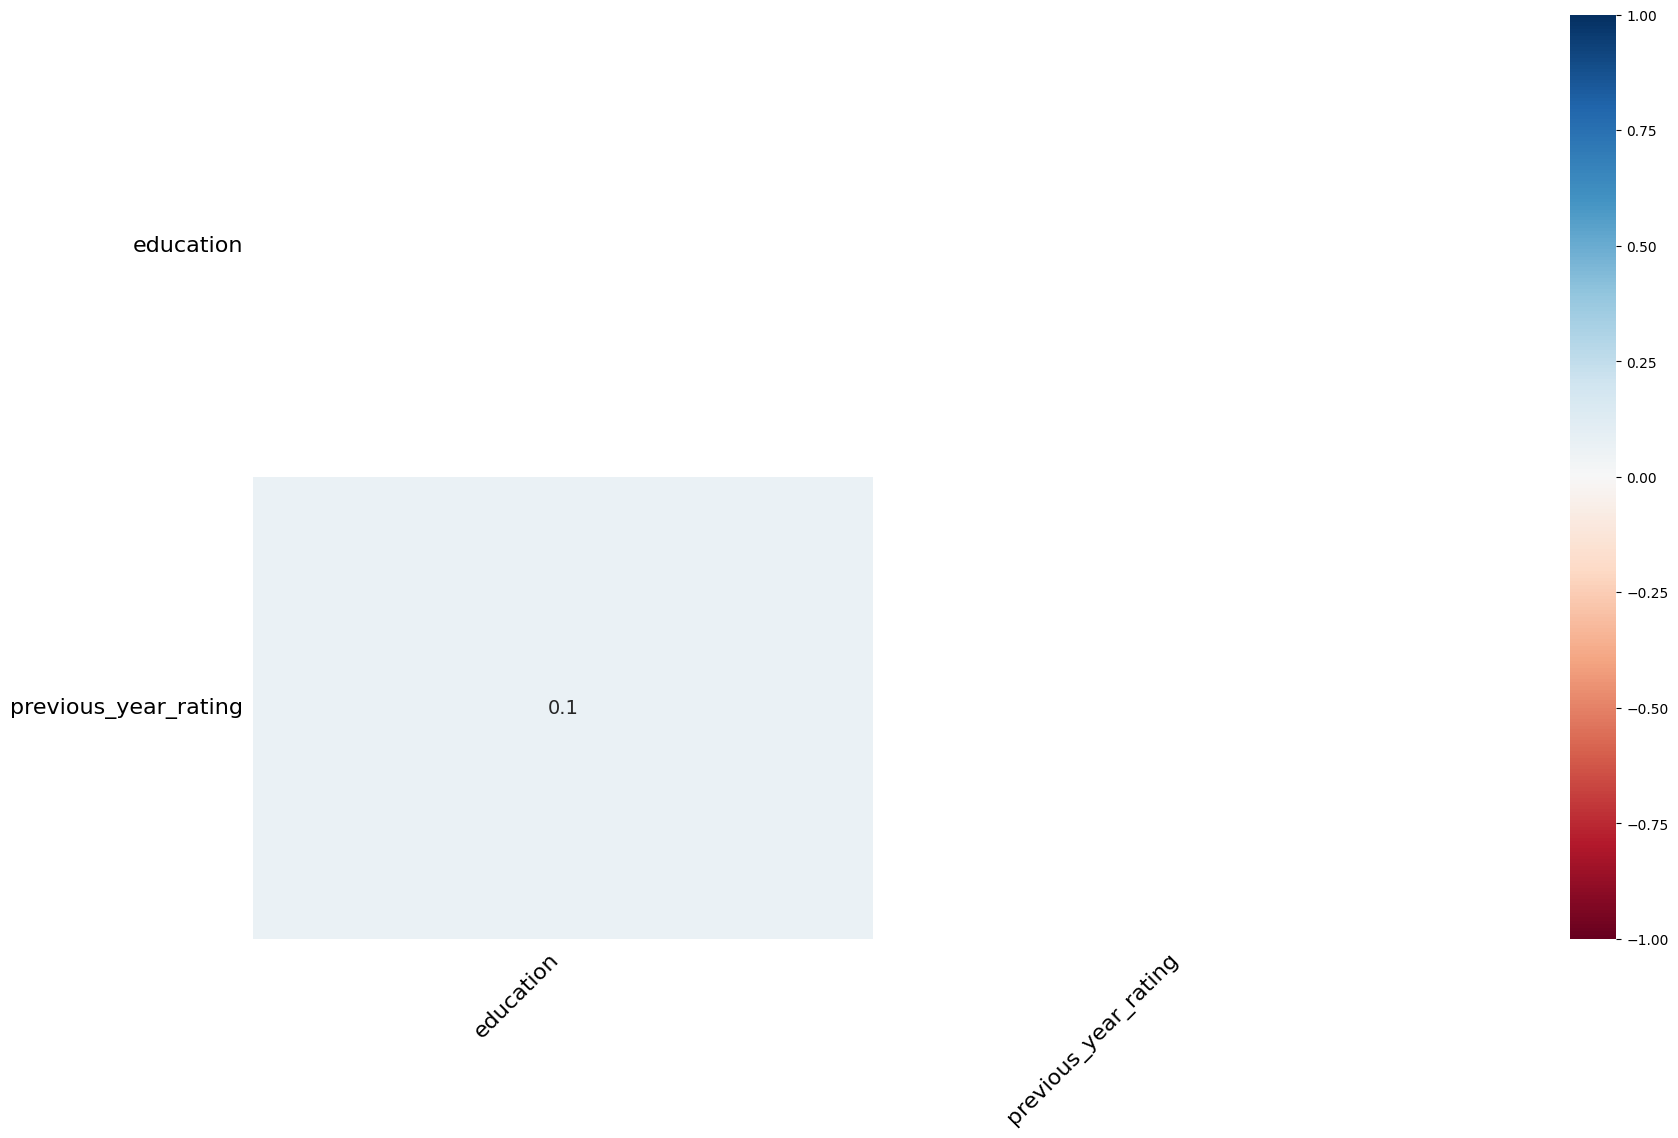

In [ ]:
msno.heatmap(df)

*Both column are very weak related on missing value , we can assume as missing at completely at random*

<Axes: >

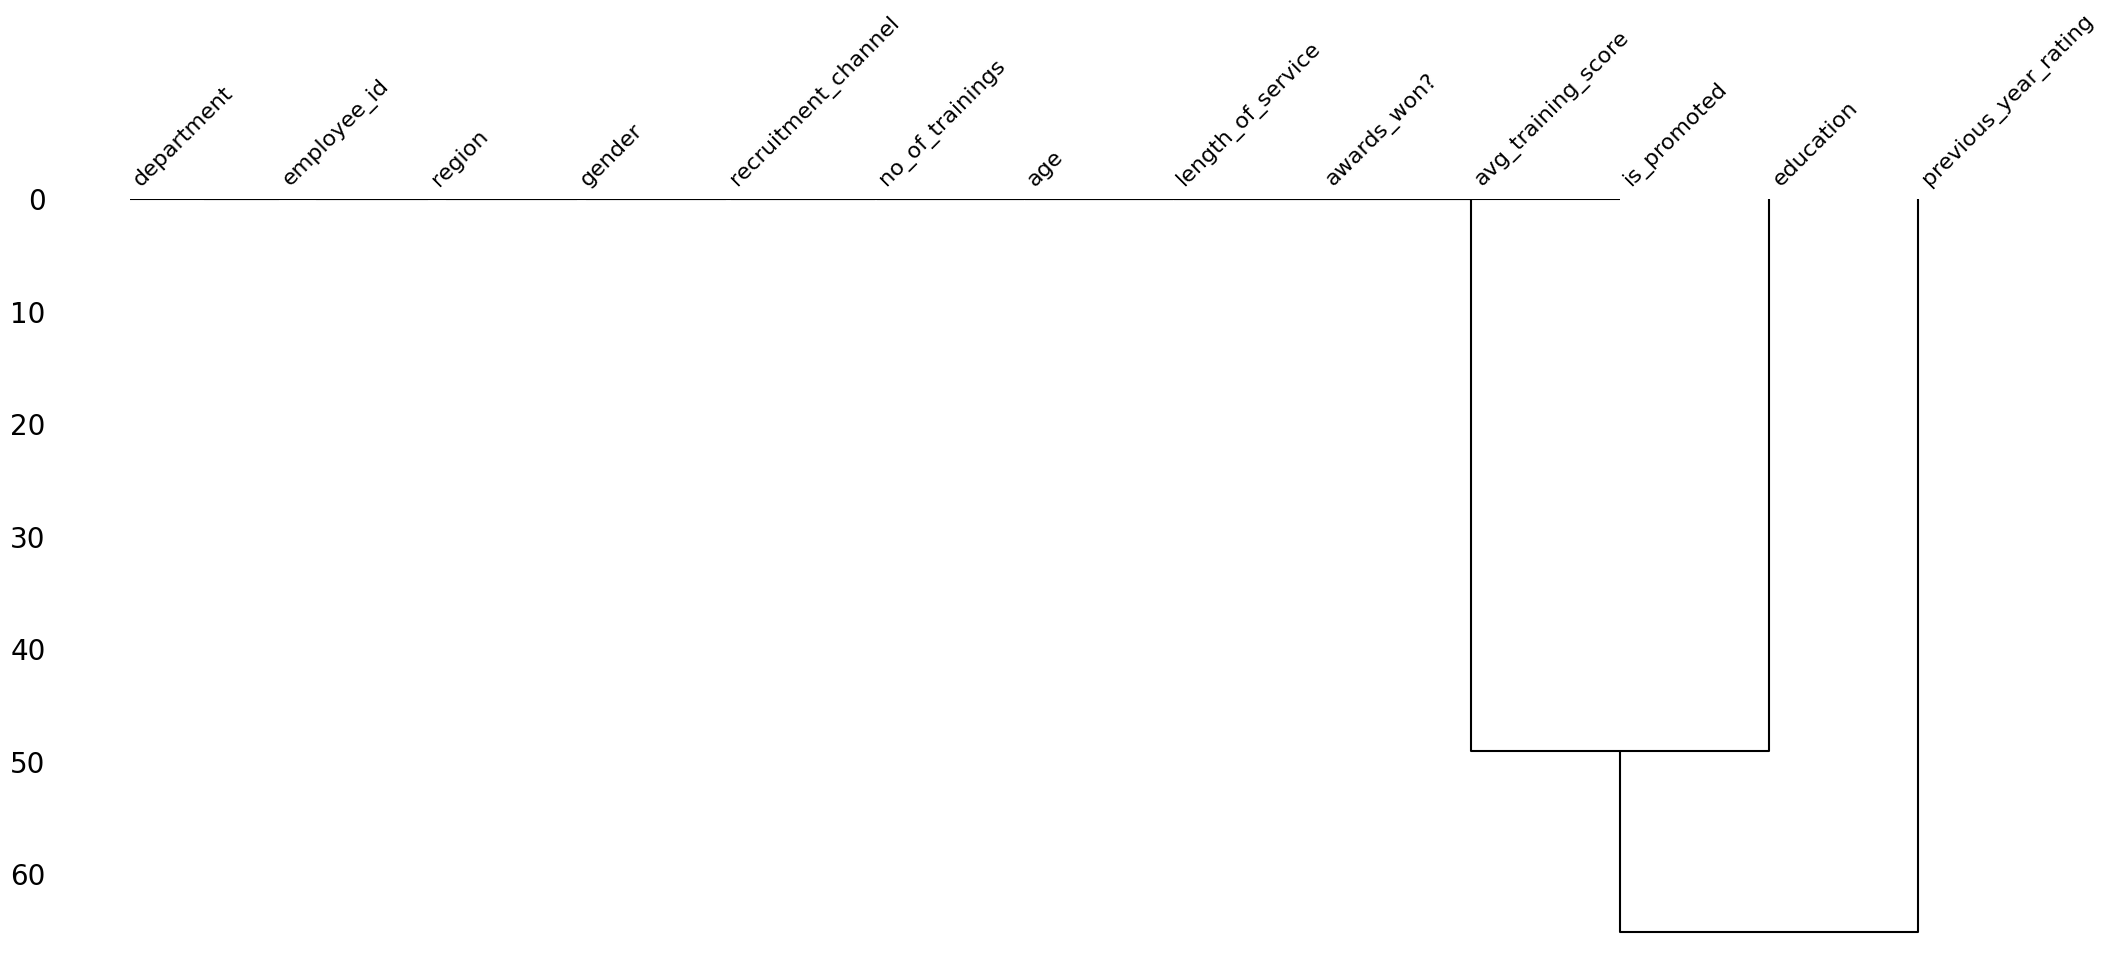

In [ ]:
msno.dendrogram(df)

*The dendrogram shows that education and previous_year_rating share similar missing-value patterns, suggesting a dependency in how these variables are recorded. avg_training_score shows a weaker relationship with this cluster, while the remaining variables appear largely independent with respect to missingness.*

In [ ]:
df[df['length_of_service'] == 1]['previous_year_rating'].isnull().sum()

np.int64(4124)

*Clearly there are freshers , which has 1 year of experience that's why previous year rating is null, we can fill it with 0*

In [ ]:
df['education'].isnull().sum()

np.int64(2409)

In [ ]:
df[df['previous_year_rating'].isnull()]['education'].isnull().sum() 

np.int64(385)

*There only 385 values in which education is null, where previous year is also null, very weak relationship,not dependent*

In [ ]:
# Box Plot Function
def plot_box_plt(x,y,df):
    plt.figure(figsize=(10,5))
    sns.boxplot(x=x,y=y,data=df)
    plt.title(f'Box Plot of {y} by {x}')
    plt.show()

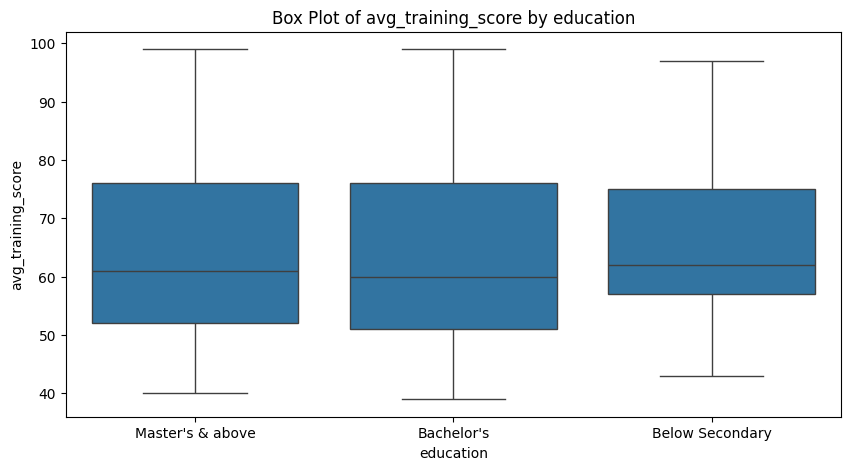

In [ ]:
plot_box_plt('education','avg_training_score',df)

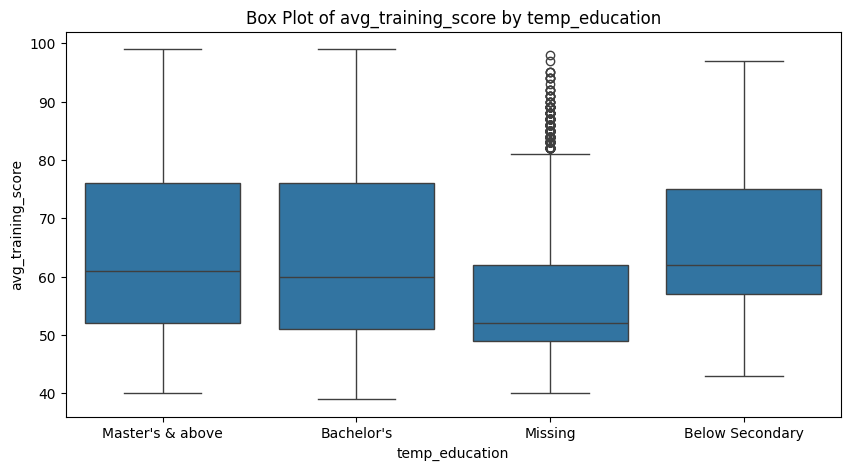

In [ ]:
df['temp_education'] = df['education']
df["temp_education"] = df["temp_education"].fillna("Missing")
plot_box_plt('temp_education','avg_training_score',df)
df.drop('temp_education', axis=1, inplace=True)

*This means education level does not strongly influence training score.*

*This confirms our earlier observation: weak relationship.*

*Some of are high performing outlier, so education alone cannot explaoin training performance*

*Missing Values may represent low qualified employees*

*We cannot drop the values, keeping Missing as a categorical may help the model*

In [ ]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='str')

In [ ]:
def plot_histogram(df): 
    columns = df.columns
    n_rows = (len(columns) + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(10,6), squeeze=False)

    for i, column in enumerate(columns):
        row = i // 2
        col = i % 2
        sns.histplot(df[column], ax=axes[row, col], kde=True)
        axes[row, col].set_title(f'Histogram of {column}')

    plt.tight_layout()
    plt.show()


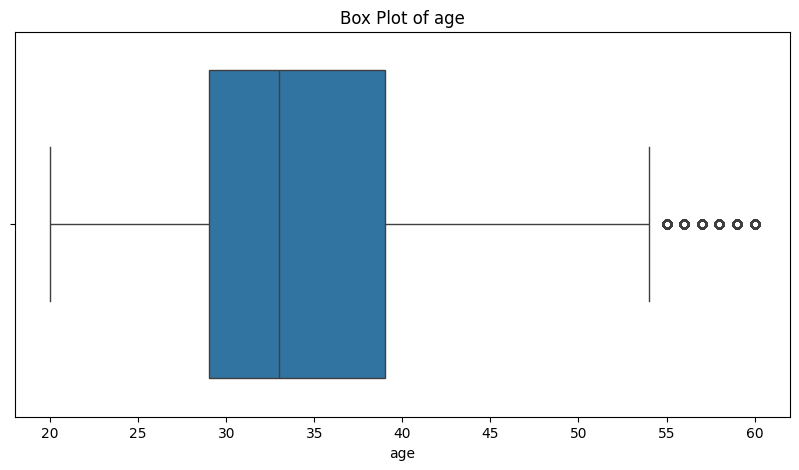

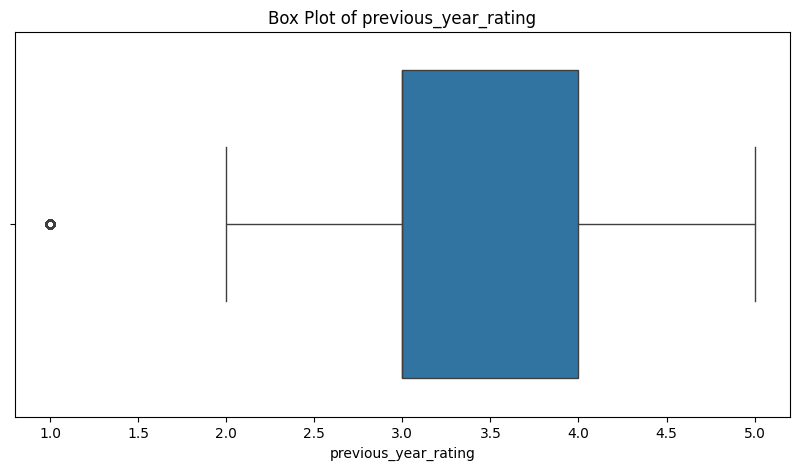

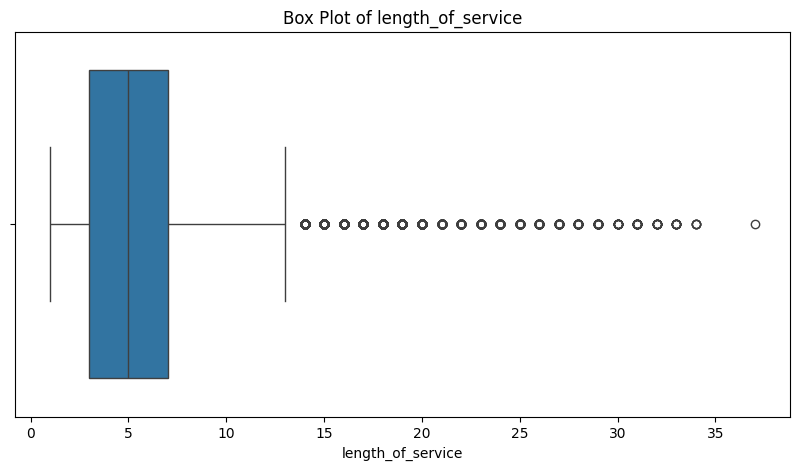

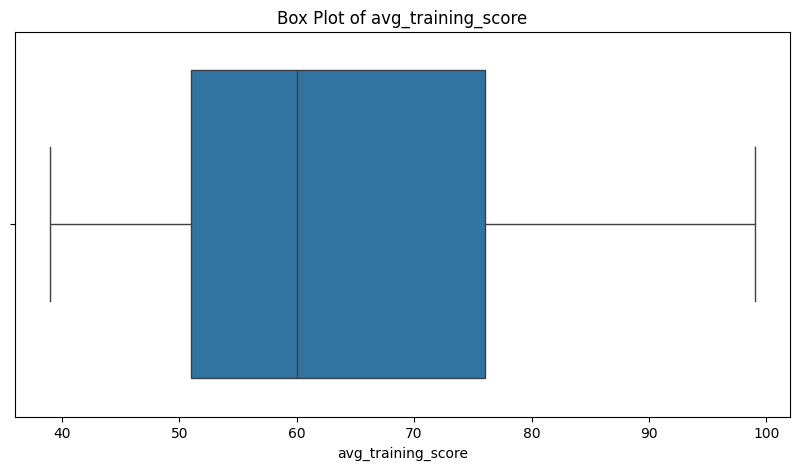

In [ ]:
for col  in ['age', 'previous_year_rating',
       'length_of_service', 'avg_training_score']:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot of {col}')
    plt.show()

*There are few outliers and can be reasonable, not contain's any extreme values. We can keep it if not rare or cap it if they are rare.*

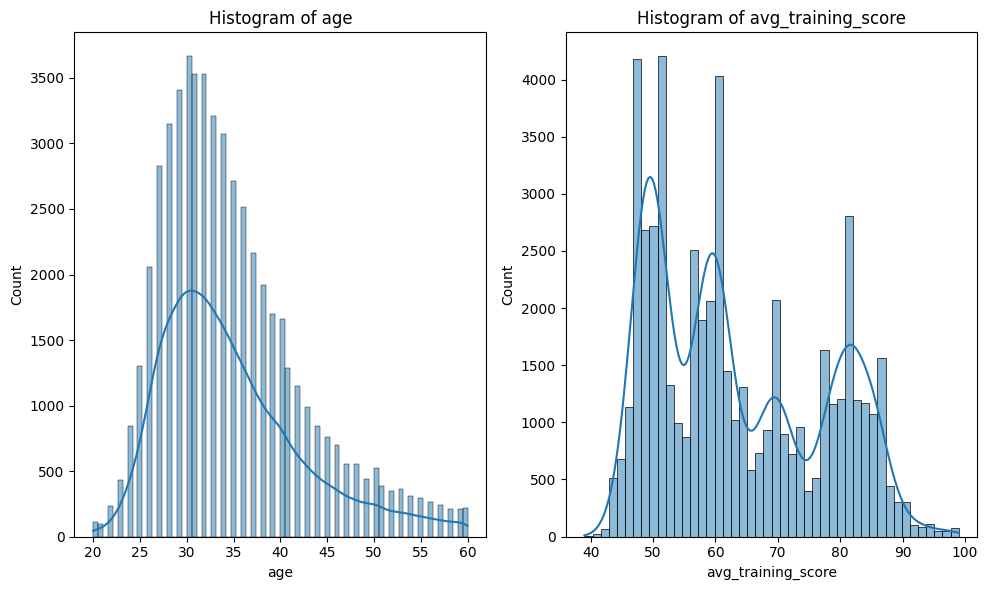

In [ ]:
plot_histogram(df[['age', 'avg_training_score']])

In [ ]:
df['avg_training_score'].mean()

np.float64(63.38675010947307)

*Age is slightly right-skewed but approximately bell-shaped. The skewness is mild, so transformation is not necessary.*

*Avg training score shows a multimodal distribution, not require transformatioon*


In [ ]:
def plot_frequency_bar_plot(df):
    columns = df.columns
    n_rows = (len(columns) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(15,14), squeeze=False)
    for i, column in enumerate(columns):
        row = i // 2
        col = i % 2
        sns.countplot(x=column, data=df, ax=axes[row, col])
        axes[row, col].set_title(f'Frequency Bar Plot of {column}')
        axes[row, col].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

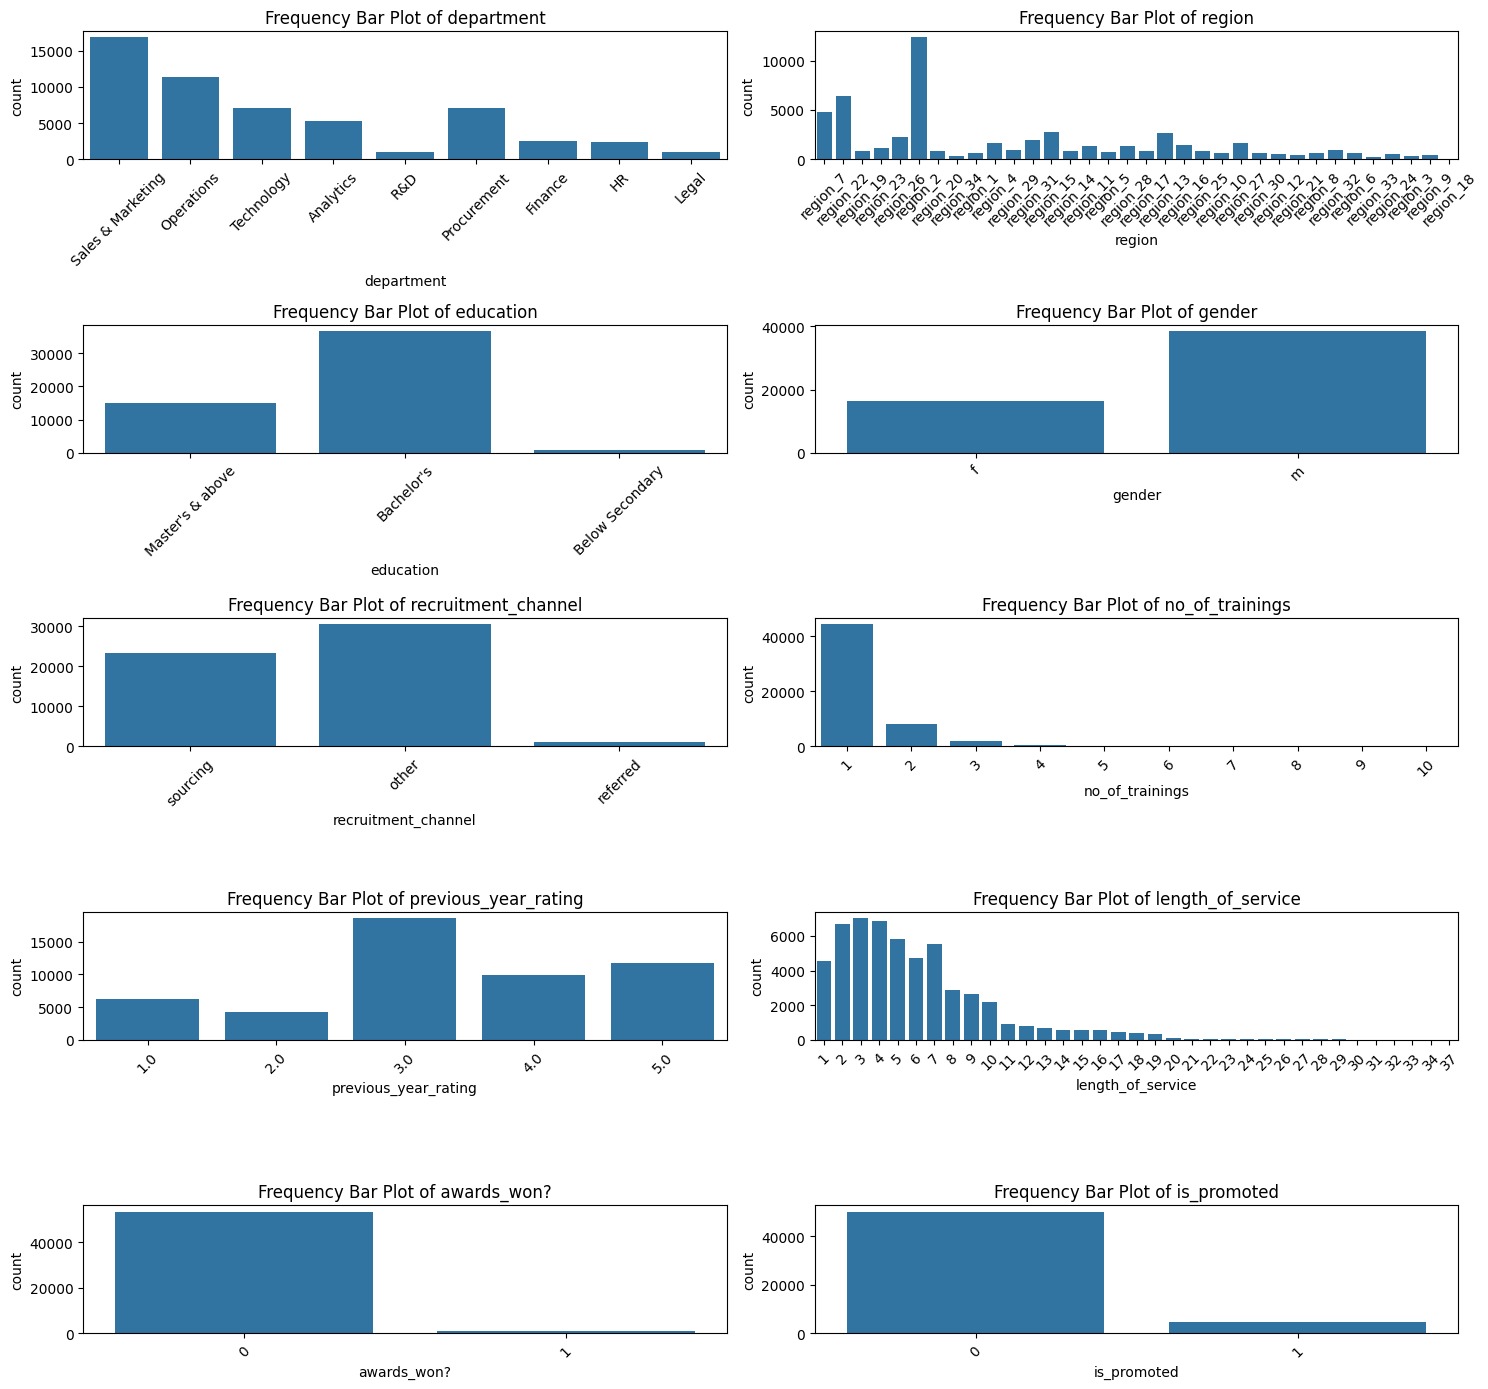

In [ ]:
plot_frequency_bar_plot(df[ ['department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'previous_year_rating',
       'length_of_service', 'awards_won?',
       'is_promoted'] ])

*Department data is not well distributed*

*Region 26 has the highest count for employment*

*Male employees are more than female*

*There are very few employees got job from referrence, and other's get job from any reason like interview On-campuss or Off-campuss*

*Many employees has done only one time training , there are very few who get 2, 3 or 4*

*Avg Rating we can say its 3, while second most ratign is 5 , so many are star performmers*

*Many Employees has 3 to 5 year of experience , every few has more than 15*

*Few employee has won awards, and got promoted.*

*The data is very imbalance, it can get bias, we can do over sampling (SMOTE), if we do down smapling the data get small, so it won't understand the data much*

In [ ]:
def plot_count_with_is_promoted(df, column):
    plt.figure(figsize=(10,5))
    sns.countplot(x=column, hue='is_promoted', data=df)
    plt.title(f'Count Plot of {column} with is_promoted')
    plt.xticks(rotation=45)
    plt.legend(title='is_promoted', loc='upper right')
    plt.show()

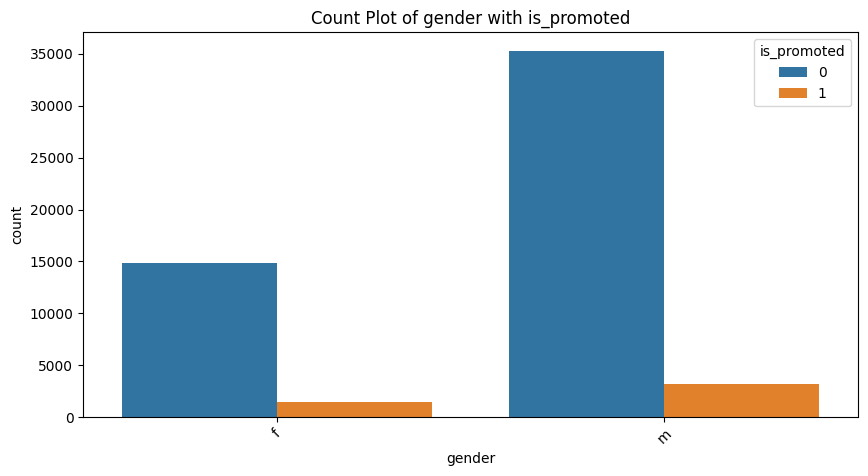

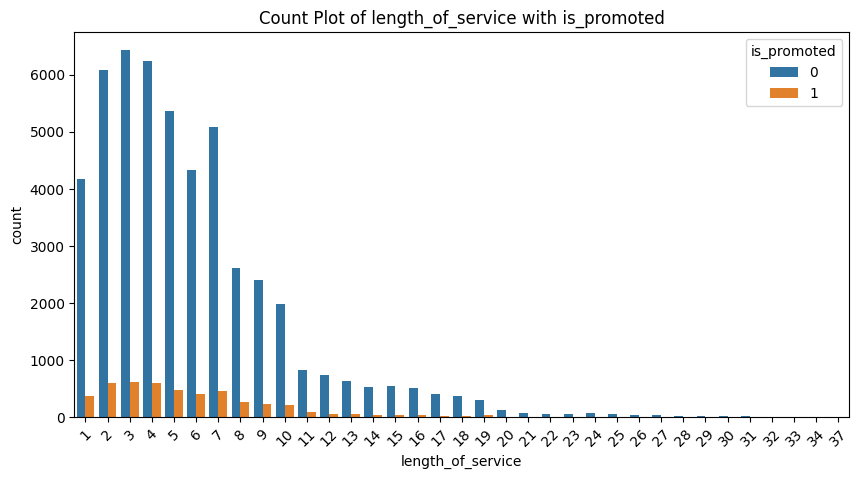

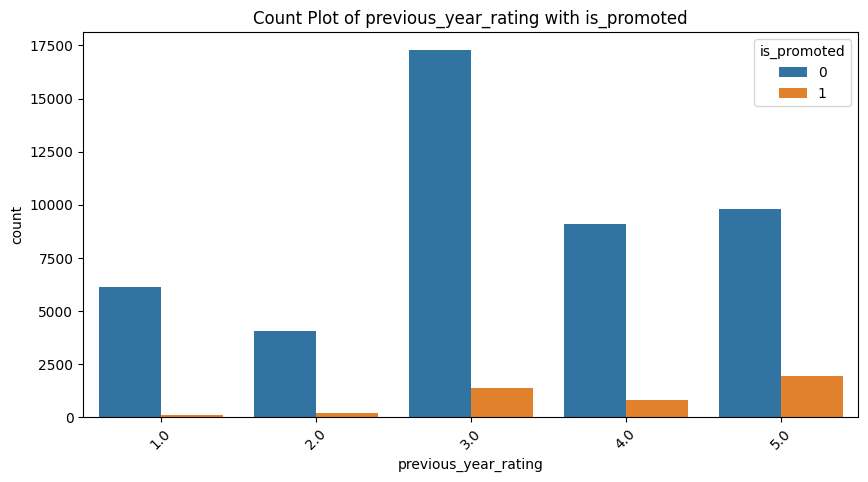

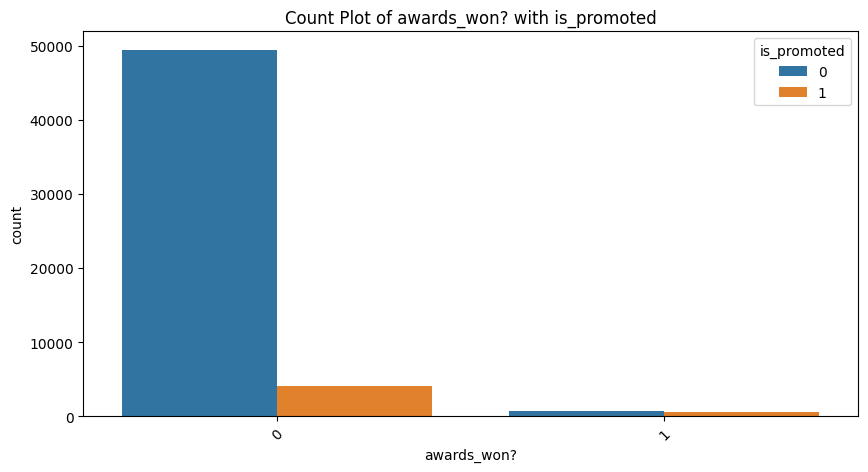

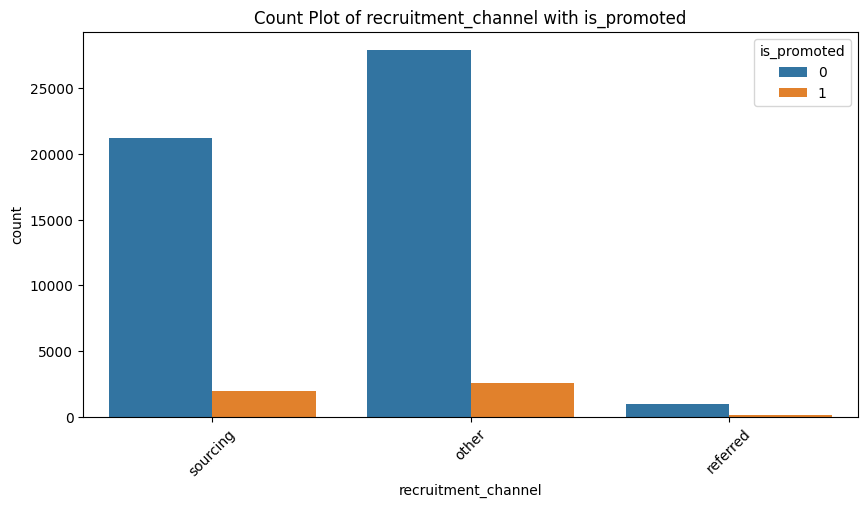

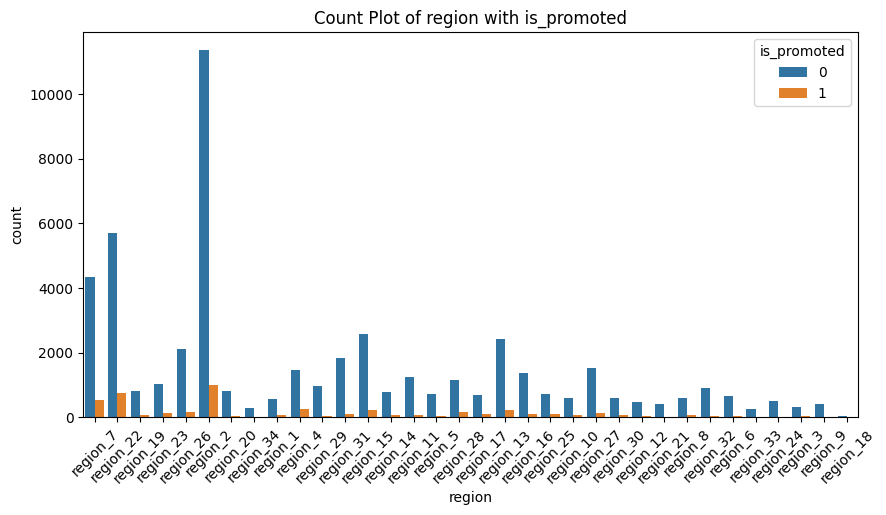

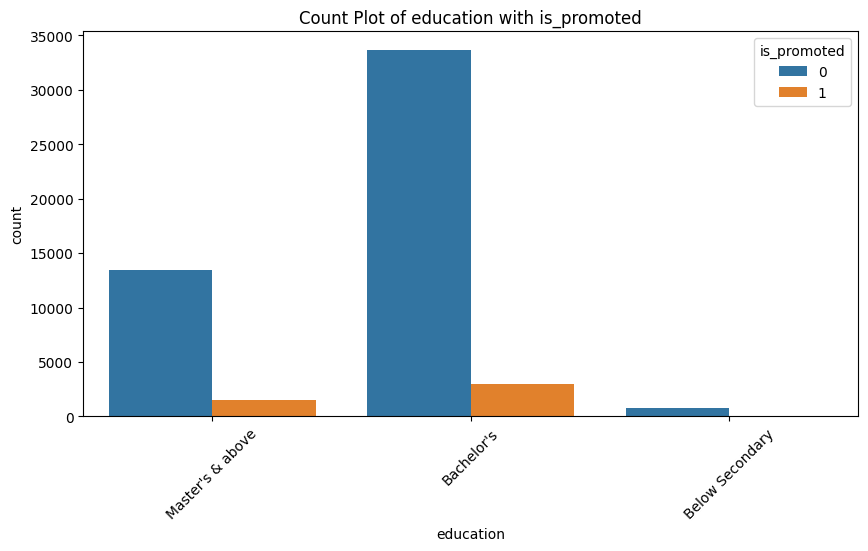

In [ ]:
for col in ['gender','length_of_service','previous_year_rating','awards_won?','recruitment_channel','region','education']:
    plot_count_with_is_promoted(df, col)

*Who have done bachelor's are got promoted more than master's, and below secondary doesn't get promoted*

*Region 26 has the highest, bcz employement from that region is also highest*

*Referred employees lowest rate of promostion than source and other*

*5 rating employees get more chance to get promoted*

*Who has win the awards are most likely to get promoted*

*Who has experince between 2 to 8 are get promoted more than experince of more than 10 year*

In [ ]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [ ]:
def plot_num_vs_num(df, col1, col2):
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col1], y=df[col2])
    plt.title(f"{col1} vs {col2}")
    plt.show()

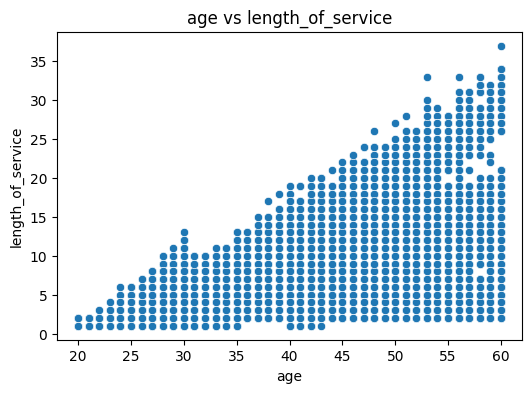

In [ ]:
plot_num_vs_num(df, "age", "length_of_service")

*As age is higher , length of service got higher*

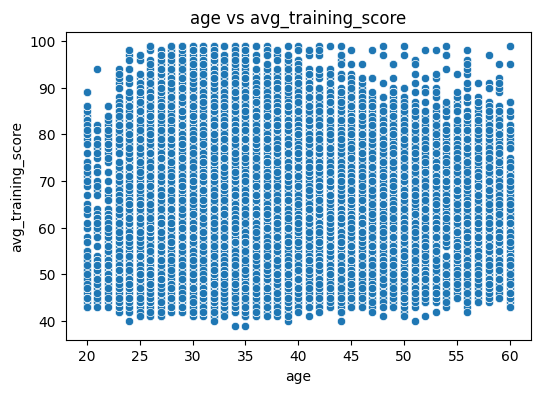

In [ ]:
plot_num_vs_num(df, "age", "avg_training_score")

*Not matter what is age, avg traning not any relationhip with age*

In [ ]:
def plot_cat_vs_cat(df, col1, col2):
    plt.figure(figsize=(7,4))
    sns.countplot(x=col1, hue=col2, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col1} vs {col2}")
    plt.show()

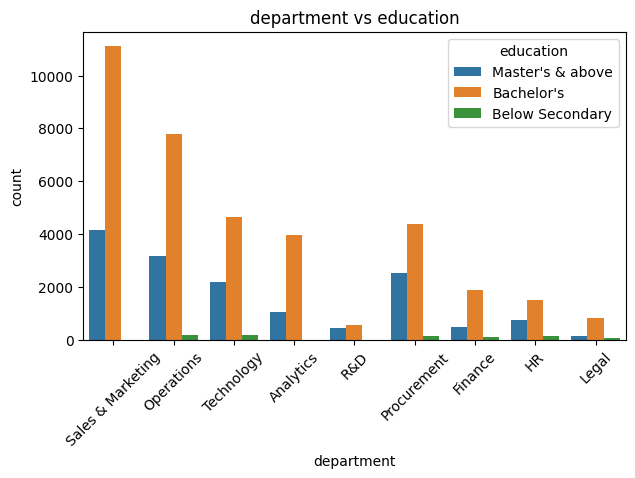

In [ ]:
plot_cat_vs_cat(df, "department", "education")

*Sales&marketing and R&D not take any employee who has below secondary education*

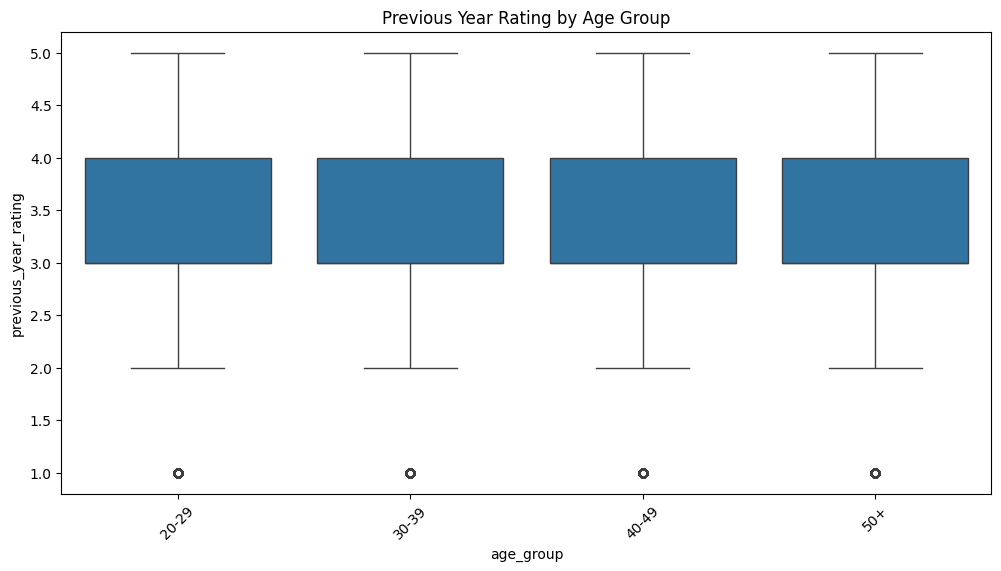

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60], labels=['20-29', '30-39', '40-49', '50+'])
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='age_group', y='previous_year_rating')
plt.title('Previous Year Rating by Age Group')
plt.xticks(rotation=45)
plt.show()

*Rating is not depending on age , its well distributed in all ages.*

In [ ]:
def plot_cat_vs_num(df, cat_col, num_col):
    plt.figure(figsize=(7,4))
    sns.boxplot(x=cat_col, y=num_col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{cat_col} vs {num_col}")
    plt.show()

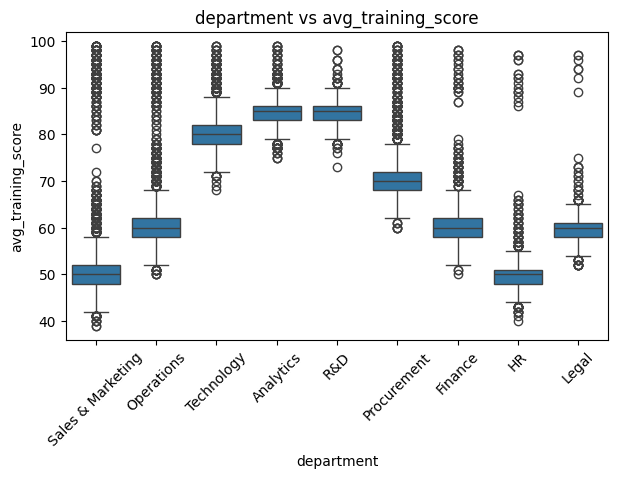

In [ ]:
plot_cat_vs_num(df, "department", "avg_training_score")

*Technology, Anaylics and R&D are highest performer employees*

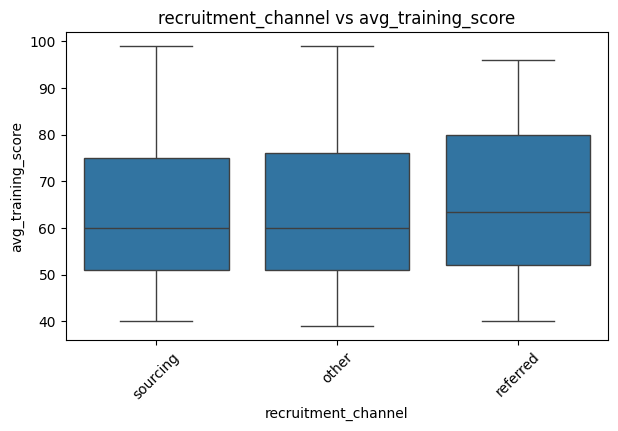

In [ ]:
plot_cat_vs_num(df,'recruitment_channel','avg_training_score')

*NO matter the channel, employee scores not depends*

In [ ]:
def plot_correlation(df, num_cols):
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

In [ ]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='str')

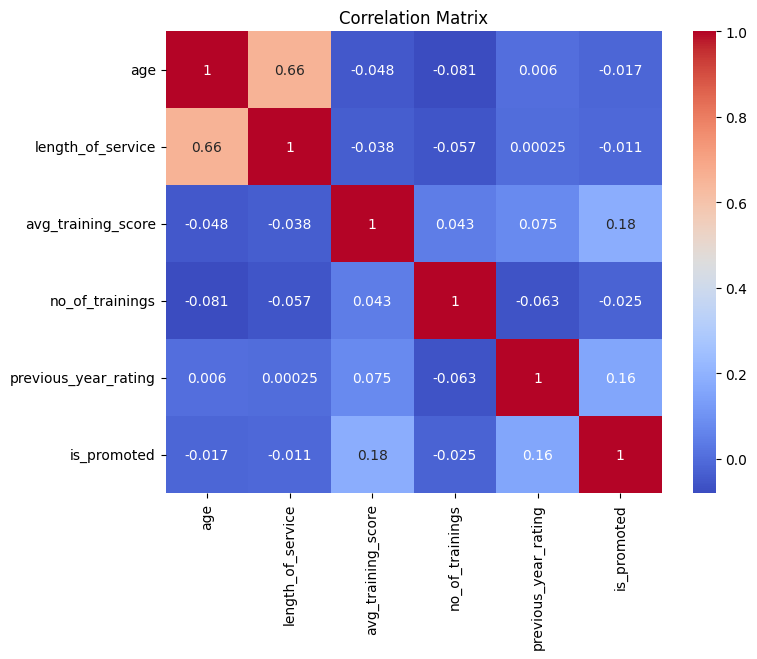

In [ ]:
num_cols = ["age","length_of_service","avg_training_score","no_of_trainings","previous_year_rating","is_promoted"]
plot_correlation(df, num_cols)

*The correlation matrix shows that age and length_of_service have a moderately strong positive relationship (0.66), which is expected in employment data. Most other variables exhibit weak correlations with each other. Promotion shows a small positive relationship with avg_training_score and previous_year_rating, suggesting employee performance metrics play a role in promotion decisions. Overall, there is limited multicollinearity among features.*

In [ ]:
def plot_cat_heatmap(df, cat_col, target="is_promoted"):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    table = pd.crosstab(df[cat_col], df[target], normalize='index')

    plt.figure(figsize=(10,15))
    sns.heatmap(table, annot=True, cmap="coolwarm")
    plt.title(f"{cat_col} vs {target}")
    plt.show()

In [ ]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='str')

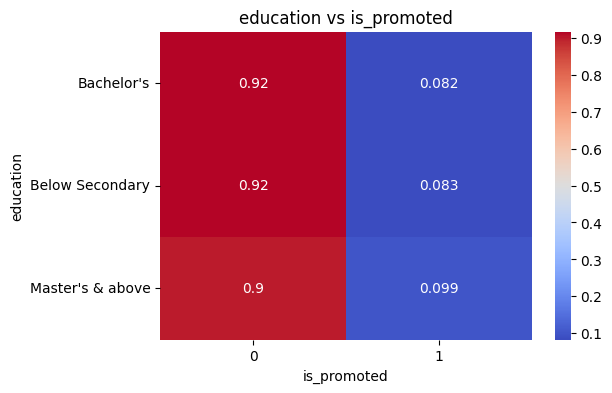

In [ ]:
plot_cat_heatmap(df, "education")

*employees with Master's degrees have slightly higher promotion rates (~10%) compared to Bachelor's (~8%), but the difference is minimal. Therefore, education may have weak predictive power for promotion.*

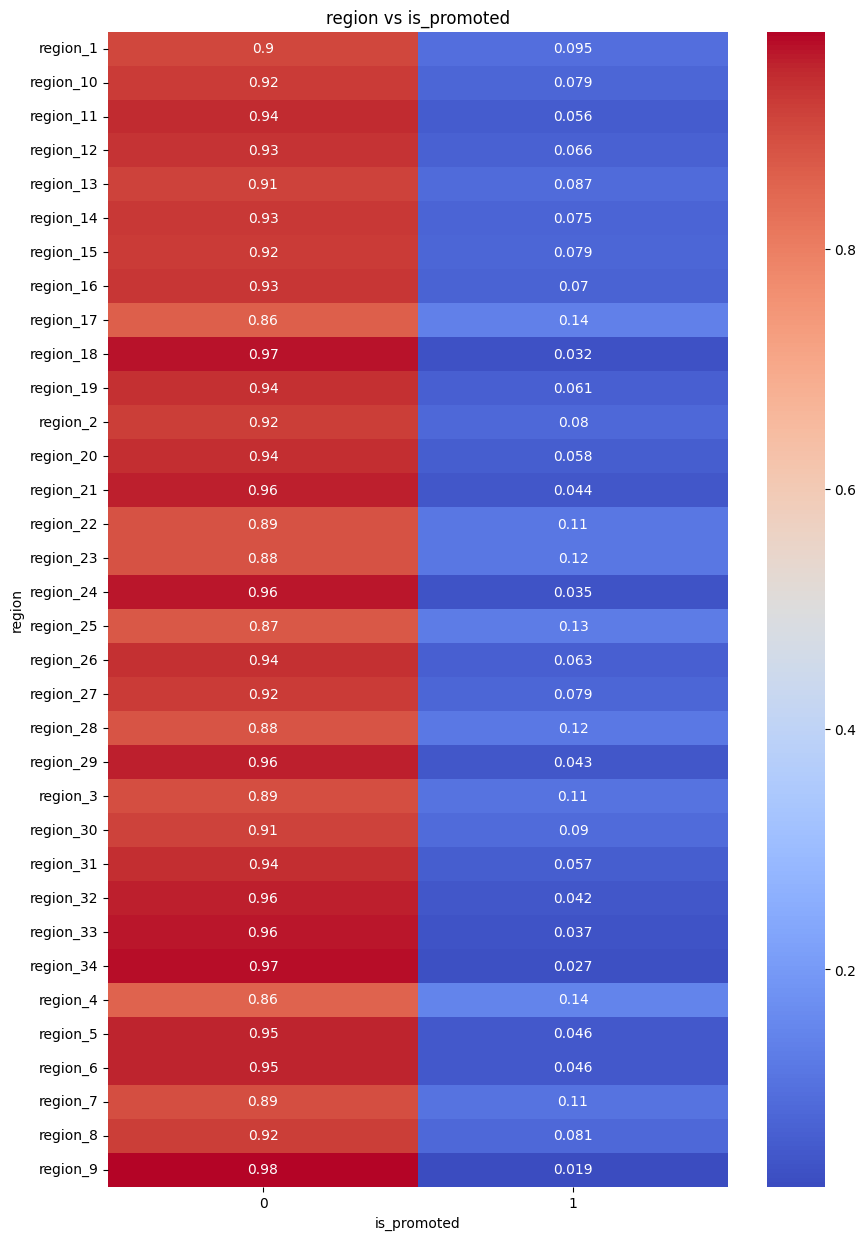

In [ ]:
plot_cat_heatmap(df,'region')

*Region : 8,30,1,13 atleast more than other higher chances to get promoted later.*

# Final Conclusion 

---

- here are no duplicate records found.

- We can consider is_promoted as Target Variable for classification model to predict employee promotion.

- Data shows imbalance in promotions (only 8.5% promoted), also department and recruitment channel imbalanced. Can use SMOTE oversampling for balance, avoid downsampling as dataset will become too small.

- Dataset has null values in education (4.4%) and previous_year_rating (7.5%). Freshers have null previous rating which we can fill with 0, education nulls show weak relation with rating and avg_score, so to make aware of missing value to model, we can add missing as a identifier.   

- Categorical columns department, region, education, gender, recruitment_channel need encoding. region by Target Encoding, Department/gender by OHE. Numerical columns age, length_of_service, avg_training_score, no_of_trainings already good range, can standardize later.

- Age and length_of_service highly correlated (0.66). Previous_year_rating and avg_training_score show small positive relation with promotion. Low multicollinearity overall, good for modeling.

- Most employees from Sales & Marketing, region_26 highest count. Males > females. Most recruitment "other", few referrals. Employees avg 35 years, 3-5 years service, rating 3 avg (many 5-star), 1 training mostly, awards rare (2%).

- Dataset shows outliers in length_of_service (very few) Can keep as business meaningful or cap by IQR. No extreme unrealistic values found.

- Data distribution shows many 3-5 year service employees, avg training score 63, promotions link to high past rating and training score. Suggest feature engineering on age_service ratio, rating trends for better model performance.

# Feature Engineering

In [14]:
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)

In [15]:
df['education'] = df['education'].fillna('missing')

In [16]:
df.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

In [17]:
df['education'].unique()

<StringArray>
['Master's & above', 'Bachelor's', 'missing', 'Below Secondary']
Length: 4, dtype: str

In [41]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=(['is_promoted','employee_id'])),df['is_promoted'],random_state=42,test_size=0.2)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((43846, 11), (43846,), (10962, 11), (10962,))

In [42]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder ,MinMaxScaler, OrdinalEncoder, PowerTransformer

#Categorical columns department, region, education, gender, recruitment_channel need encoding. region by Target Encoding,
#  Department/gender by OHE. Numerical columns age, length_of_service, avg_training_score, no_of_trainings already good range, can standardize later.

processor = ColumnTransformer(
    transformers=[
        ('pw', PowerTransformer(method='yeo-johnson'), ['length_of_service']),
        ('num', MinMaxScaler(), ['age', 'avg_training_score','length_of_service']),
        ('target', TargetEncoder(), ['region']),
        ('cat', OneHotEncoder(), ['department', 'gender', 'recruitment_channel']),
        ('ordinal', OrdinalEncoder(categories=[[ 'missing','Below Secondary', 'Bachelor\'s', 'Master\'s & above']]), ['education'])
    ],
    remainder='passthrough'
)

In [45]:
processor.fit(X_train,y_train)
X_train_processed = processor.transform(X_train)
X_test_Processed = processor.transform(X_test)

In [46]:
X_train = pd.DataFrame(X_train_processed,index=X_train.index,columns=processor.get_feature_names_out())
X_test = pd.DataFrame(X_test_Processed,index=X_test.index,columns=processor.get_feature_names_out())
X_train.head()

,pw__length_of_service,num__age,num__avg_training_score,num__length_of_service,target__region,cat__department_Analytics,cat__department_Finance,cat__department_HR,cat__department_Legal,cat__department_Operations,...,cat__department_Technology,cat__gender_f,cat__gender_m,cat__recruitment_channel_other,cat__recruitment_channel_referred,cat__recruitment_channel_sourcing,ordinal__education,remainder__no_of_trainings,remainder__previous_year_rating,remainder__awards_won?
3872,0.067854,0.275,0.150000,0.111111,0.059265,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,5.0,0.0
11619,-0.247268,0.350,0.650000,0.083333,0.091644,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0
36178,-0.247268,0.225,0.633333,0.083333,0.114724,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,2.0,3.0,4.0,0.0
29884,1.723784,0.850,0.133333,0.388889,0.080089,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,4.0,0.0
22968,0.332478,0.275,0.783333,0.138889,0.105312,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,5.0,0.0


In [48]:
def evaluate_model(y_test, y_pred):

    accuracy = accuracy_score(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)

    return accuracy,cm,precision,recall

In [49]:
def train_and_evaluate(models, X_train, X_test, y_train, y_test):

    results = []

    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Evaluate
        accuracy, cm, precision, recall= evaluate_model(y_test, y_pred)

        results.append({
            "Model": name,
            "Accuracy" : accuracy,
            "confusion_matrix" : cm,
            "Precision" : precision,
            "Recall" : recall
        })

    return pd.DataFrame(results)

In [51]:
models = {
    "LogisticRegression" : LogisticRegression(penalty="l2",l1_ratio=0.8),
    "LogisticRegressionCV " : LogisticRegressionCV(cv=5),
    "KNN" : KNeighborsClassifier(n_neighbors=10),
    "SVC" : SVC(),
    "DecisionTreeClassifier" : DecisionTreeClassifier(),
    "RandomForest" : RandomForestClassifier(),
    "GradientBoostingClassifier" : GradientBoostingClassifier(),
    "AdaBoostClassifier" : AdaBoostClassifier(),
    "XGBClassifier" : XGBClassifier()
}

In [52]:
train_and_evaluate(models,X_train,X_test,y_train,y_test)

/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.8. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/lin

,Model,Accuracy,confusion_matrix,Precision,Recall
0,LogisticRegression,0.937968,"[[10045, 9], [671, 237]]",0.963415,0.261013
1,LogisticRegressionCV,0.939792,"[[10040, 14], [646, 262]]",0.949275,0.288546
2,KNN,0.918902,"[[10043, 11], [878, 30]]",0.731707,0.033040
3,SVC,0.925926,"[[10053, 1], [811, 97]]",0.989796,0.106828
4,DecisionTreeClassifier,0.884328,"[[9313, 741], [527, 381]]",0.339572,0.419604
5,RandomForest,0.937603,"[[10002, 52], [632, 276]]",0.841463,0.303965
6,GradientBoostingClassifier,0.941069,"[[10042, 12], [634, 274]]",0.958042,0.301762
7,AdaBoostClassifier,0.926747,"[[10041, 13], [790, 118]]",0.900763,0.129956
8,XGBClassifier,0.942529,"[[10024, 30], [600, 308]]",0.911243,0.339207


### without sampling , models achieved high accuracy but failed to detect the minority class (low recall)

In [54]:
y_test.value_counts()

is_promoted
0    10054
1      908
Name: count, dtype: int64

In [ ]:
y_train.value_counts()

is_promoted
0    40086
1     3760
Name: count, dtype: int64

In [55]:
X_train.shape,y_train.shape

((43846, 23), (43846,))

### Balancing Data with SMOTE

In [58]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [59]:
X_resampled.shape,y_resampled.shape

((80172, 23), (80172,))

In [60]:
train_and_evaluate(models,X_resampled,X_test,y_resampled,y_test)

/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.8. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/lin

,Model,Accuracy,confusion_matrix,Precision,Recall
0,LogisticRegression,0.759533,"[[7744, 2310], [326, 582]]",0.201245,0.640969
1,LogisticRegressionCV,0.757708,"[[7730, 2324], [332, 576]]",0.198621,0.634361
2,KNN,0.785167,"[[8201, 1853], [502, 406]]",0.179726,0.447137
3,SVC,0.794654,"[[8142, 1912], [339, 569]]",0.229343,0.626652
4,DecisionTreeClassifier,0.867907,"[[9173, 881], [567, 341]]",0.279051,0.375551
5,RandomForest,0.918810,"[[9749, 305], [585, 323]]",0.514331,0.355727
6,GradientBoostingClassifier,0.897738,"[[9448, 606], [515, 393]]",0.393393,0.432819
7,AdaBoostClassifier,0.780879,"[[8050, 2004], [398, 510]]",0.202864,0.561674
8,XGBClassifier,0.940887,"[[10004, 50], [598, 310]]",0.861111,0.341410


### After applying sampling, recall improved significantly, making models more reliable. Among all, XGBoost provided the best balance between accuracy, precision, and recall.

## Hypertunning

In [74]:
param_grid = [
    {
        'C' : [0.001, 0.01, 0.1, 1, 10, 100],
        'l1_ratio' : [0,0.2,0.4,0.6,0.8,1.0],
        'solver' : ['liblinear','lbfgs','saga','newton-cg'],
        'class_weight': [
        {0:1, 1:1},
        {0:1, 1:2},
        {0:1, 1:3},
        {0:1, 1:5},
        {0:1, 1:10}
        ]
    }
]

In [75]:
lr = LogisticRegression()

In [83]:
grid = RandomizedSearchCV(lr,param_grid,scoring='recall',cv=4,n_iter=100)
grid.fit(X_train,y_train)

/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tarun.nagpal@simform.dom/Documents/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'C': [0.001, 0.01, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2}, ...], 'l1_ratio': [0, 0.2, ...], 'solver': ['liblinear', 'lbfgs', ...]}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 